In [ ]:
# 线性回归
import torch
import random
import matplotlib.pyplot as plt

In [3]:
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape) # 加上标准差为0.01的高斯噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

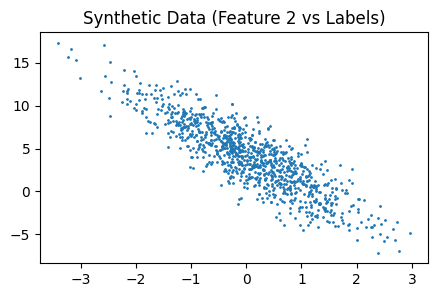

In [4]:
plt.figure(figsize=(5, 3))
# 必须先 detach() 分离计算图并转为 numpy 才能用 matplotlib 绘制
plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), s=1)
plt.title("Synthetic Data (Feature 2 vs Labels)")
plt.show()

In [5]:
def data_iter(batch_size, features, labels):
    """生成小批量数据迭代器"""
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices) # 随机打乱样本读取顺序
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [6]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [7]:
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [8]:
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad(): # 更新参数时不计算梯度，避免破坏原有的计算图
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() # 每次更新后务必将梯度清零

In [9]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
batch_size = 10

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # X和y的小批量损失
        # l 的形状是 (batch_size, 1)，而不是标量
        # 我们把 l 中的所有元素加起来求和，再计算关于 [w, b] 的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) # 使用梯度更新参数
    
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

print(f'\nw 的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b 的估计误差: {true_b - b}')

epoch 1, loss 0.043507
epoch 2, loss 0.000166
epoch 3, loss 0.000048

w 的估计误差: tensor([-8.6308e-05, -5.8675e-04], grad_fn=<SubBackward0>)
b 的估计误差: tensor([0.0003], grad_fn=<RsubBackward1>)
